# Studio qualità — Entity Graph

Analisi **as-is** di `pathos graph` (`build_entity_links`, co-occorrenza entità in eventi
condivisi) sul DB reale. Nessun fix: mappa struttura e criticità del grafo con esempi concreti.

Riferimento codice: `pathosphere/semantic/graph.py`. Nota: SOLO `relation_type='co-occurs'`
viene popolato — le relazioni tipate dello schema (`depends_on`, `supplies`, `sanctions`…)
non sono mai scritte da nessun modulo attuale.

In [1]:
import sys, struct, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pathosphere").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from pathosphere.db.schema import get_connection

DB_PATH = REPO_ROOT / "data" / "db" / "pathosphere.db"
conn = get_connection(DB_PATH)
print(f"DB: {DB_PATH}  exists={DB_PATH.exists()}")

def q(sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)

q("SELECT COUNT(*) AS raw_documents FROM raw_documents")


DB: /Users/dom/Documents/GitHub/pathosphere/data/db/pathosphere.db  exists=True


,raw_documents
0,176477


## 1. Composizione entity_links

In [2]:
links_summary = q("""
SELECT relation_type, COUNT(*) AS n, AVG(strength) AS avg_strength,
       MIN(strength) AS min_s, MAX(strength) AS max_s
FROM entity_links GROUP BY relation_type
""")
links_summary

,relation_type,n,avg_strength,min_s,max_s
0,co-occurs,89838,0.151882,0.1,1.0


## 2. Grado nodi

In [3]:
deg = q("""
SELECT entity_id, COUNT(*) AS degree FROM (
  SELECT entity_a AS entity_id FROM entity_links
  UNION ALL
  SELECT entity_b AS entity_id FROM entity_links
) GROUP BY entity_id ORDER BY degree DESC
""")
deg["degree"].describe()

count    10192.000000
mean        17.629121
std         53.753014
min          1.000000
25%          3.000000
50%          9.000000
75%         22.000000
max       3962.000000
Name: degree, dtype: float64

In [4]:
entities_all = q("SELECT id, name, entity_type FROM entities")
top_degree = deg.head(20).merge(entities_all, left_on="entity_id", right_on="id")
top_degree[["name", "entity_type", "degree"]]

,name,entity_type,degree
0,GDELT,company,3962
1,US,location,1459
2,POLICE,company,922
3,span><strong,other,674
4,Iran,location,640
5,GOVERNMENT,other,639
6,Trump,person,603
7,Pakistan,location,588
8,China,location,573
9,Donald Trump,person,506


### 2b. Nodo 'GDELT' — hub artificiale

Come emerso nello studio extract (`study_02_extract.ipynb`), l'entità `GDELT` è un artefatto
NER (leak del prefisso titolo sintetico), non un'entità reale. Se compare in cima al grado
nodi sopra, è un singolo hub artificiale che co-occorre con tutto ciò che è successo in un
evento di origine GDELT — potenzialmente la causa diretta di un'unica componente gigante
nel grafo (vedi sezione 3).

In [5]:
gdelt_deg = top_degree[top_degree["name"] == "GDELT"]
total_edges = int(q("SELECT COUNT(*) AS n FROM entity_links")["n"][0])
if len(gdelt_deg):
    gd = int(gdelt_deg.iloc[0]["degree"])
    print(f"Grado nodo 'GDELT': {gd} su {total_edges} archi totali ({gd / total_edges * 100:.1f}%).")
else:
    print("'GDELT' non è tra i top-20 per grado in questo run.")

Grado nodo 'GDELT': 3962 su 89838 archi totali (4.4%).


## 3. Hairball check — componenti connesse

Union-find manuale sui link, per vedere se il grafo è un'unica massa indistinta o si separa
in componenti sensate.

In [6]:
edges = q("SELECT entity_a, entity_b FROM entity_links")
parent = {}

def find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[rx] = ry

for _, r in edges.iterrows():
    union(int(r.entity_a), int(r.entity_b))

roots = Counter(find(x) for x in parent)
comp_sizes = pd.Series(sorted(roots.values(), reverse=True))
print(f"nodi coinvolti in almeno 1 link: {len(parent)}")
print(f"numero componenti connesse: {len(roots)}")
if len(comp_sizes):
    print(f"dimensione componente più grande: {comp_sizes.iloc[0]} "
          f"({comp_sizes.iloc[0] / len(parent) * 100:.1f}% dei nodi collegati)")
comp_sizes.head(10)

nodi coinvolti in almeno 1 link: 10192
numero componenti connesse: 127
dimensione componente più grande: 9666 (94.8% dei nodi collegati)


0    9666
1      25
2      14
3      13
4      13
5      11
6      10
7       9
8       9
9       9
dtype: int64

## 4. Strength — saturazione

link con strength=1.0 (saturi, >=10 co-occorrenze): 2233 su 89838 (2.5%)


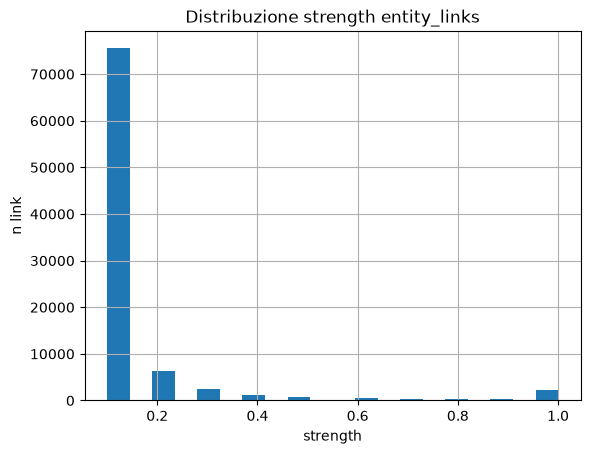

In [7]:
strengths = q("SELECT strength FROM entity_links")
saturated = (strengths["strength"] >= 0.999).sum()
print(f"link con strength=1.0 (saturi, >=10 co-occorrenze): {saturated} su {len(strengths)} "
      f"({saturated / len(strengths) * 100:.1f}%)" if len(strengths) else "nessun link")
strengths["strength"].hist(bins=20)
plt.xlabel("strength"); plt.ylabel("n link"); plt.title("Distribuzione strength entity_links")
plt.show()

## 5. Top archi per strength — sensati vs rumore

In [8]:
top_edges = q("""
SELECT ea.name AS a, eb.name AS b, l.strength
FROM entity_links l
JOIN entities ea ON ea.id = l.entity_a
JOIN entities eb ON eb.id = l.entity_b
ORDER BY l.strength DESC LIMIT 30
""")
top_edges

,a,b,strength
0,GDELT,WASHINGTON,1.0
1,GDELT,FEDERAL,1.0
2,GDELT,COMPANIES,1.0
3,GDELT,CUBA,1.0
4,GDELT,EUROPEAN,1.0
5,GDELT,IRAN,1.0
6,GDELT,LAWYER,1.0
7,GDELT,ATTORNEY,1.0
8,GDELT,FLORIDA,1.0
9,GDELT,COLORADO,1.0


## 6. Caso d'uso: "se chiude Hormuz, chi soffre?"

Test diretto della promessa architetturale del grafo entità (CLAUDE.md: "grafo entità...
più potente della sola ricerca semantica per il ragionamento causale").

In [9]:
hormuz = q("SELECT id, name, entity_type FROM entities WHERE name LIKE '%HORMUZ%' OR name LIKE '%Hormuz%'")
hormuz

,id,name,entity_type
0,2679,Hormuz,location
1,1444,Hormuz,person
2,5324,Hormuz Strait,location
3,1874,Strait of Hormuz,location
4,2686,"Strait of Hormuz,&rdquo;</em",location
5,2745,"Strait of Hormuz,&rdquo;</em> Araghchi",location
6,2353,Strait of Hormuz.</p,location
7,4466,Strait of Hormuz.<p>Pakistani,location
8,3333,estreito-de-hormuz/,location
9,10540,opec-approves-fourth-oil-output-quota-hike-sin...,location


In [10]:
if len(hormuz):
    eid = int(hormuz.iloc[0].id)
    neighbors = q("""
        SELECT ea.name AS a, eb.name AS b, l.strength
        FROM entity_links l
        JOIN entities ea ON ea.id = l.entity_a JOIN entities eb ON eb.id = l.entity_b
        WHERE l.entity_a = ? OR l.entity_b = ?
        ORDER BY l.strength DESC
    """, params=(eid, eid))
    print(f"{len(neighbors)} vicini nel grafo per '{hormuz.iloc[0]['name']}'")
    display(neighbors)
else:
    print("Nessuna entità 'Hormuz' trovata in DB — il chokepoint non è rappresentato come "
          "entità NER. I dati PortWatch entrano come chokepoint_metrics/eventi separati, "
          "mai collegati a entities/entity_links: il caso d'uso citato in CLAUDE.md non è "
          "attualmente eseguibile sul grafo così come costruito.")

47 vicini nel grafo per 'Hormuz'


,a,b,strength
0,US,Hormuz,0.2
1,Iran,Hormuz,0.2
2,Iranian,Hormuz,0.2
3,Donald Trump,Hormuz,0.2
4,Washington,Hormuz,0.2
5,Hormuz,The waterway,0.1
6,Hormuz,CENTCOM,0.1
7,Hormuz,US Central Command,0.1
8,Hormuz,hostilities.</p,0.1
9,Hormuz,country&rsquo;s,0.1


## Sintesi criticità osservate in questo run

In [11]:
print("--- Sintesi (valori da questo run) ---")
if len(gdelt_deg):
    print(f"1. Nodo 'GDELT' (artefatto NER, non entità reale): grado {gd}/{total_edges} archi "
          f"({gd / total_edges * 100:.1f}%) — hub artificiale, causa diretta più probabile "
          "della componente gigante qui sotto.")
print(f"2. relation_type presenti: {list(links_summary['relation_type'])} — "
      "solo co-occorrenza, nessuna relazione tipata (depends_on/supplies/...) mai popolata.")
if len(comp_sizes):
    print(f"3. Componente connessa più grande: {comp_sizes.iloc[0]}/{len(parent)} nodi "
          f"({comp_sizes.iloc[0] / len(parent) * 100:.1f}%) — hairball se questa quota è alta.")
print(f"4. Link saturi a strength=1.0: {saturated}/{len(strengths)} — soglia 10 co-occorrenze "
      "satura in fretta su entità molto menzionate, appiattendo il segnale di forza relazione.")
print(f"5. Caso Hormuz: {'presente' if len(hormuz) else 'ASSENTE'} nel grafo entità.")

--- Sintesi (valori da questo run) ---
1. Nodo 'GDELT' (artefatto NER, non entità reale): grado 3962/89838 archi (4.4%) — hub artificiale, causa diretta più probabile della componente gigante qui sotto.
2. relation_type presenti: ['co-occurs'] — solo co-occorrenza, nessuna relazione tipata (depends_on/supplies/...) mai popolata.
3. Componente connessa più grande: 9666/10192 nodi (94.8%) — hairball se questa quota è alta.
4. Link saturi a strength=1.0: 2233/89838 — soglia 10 co-occorrenze satura in fretta su entità molto menzionate, appiattendo il segnale di forza relazione.
5. Caso Hormuz: presente nel grafo entità.
